# Ecosistema actual, Huggingface y modelos pre entrenados.

---

# Modelos:

## 1. [Swin Transformer](https://huggingface.co/docs/transformers/model_doc/swin)
- **Tipo:** Transformer jerárquico.
- **Características:**
  - Utiliza ventanas deslizantes (windowed attention) para atención local.
  - Crea representaciones jerárquicas a partir de imágenes.
  - Mejora la escalabilidad en procesamiento de imágenes de alta resolución.

## 2. [Convolutional Vision Transformer (CvT)](https://huggingface.co/docs/transformers/model_doc/cvt)
- **Tipo:** Híbrido CNN y Transformer.
- **Características:**
  - Aplica convoluciones iniciales para captura de características locales.
  - Utiliza bloques de Transformer para modelar relaciones globales.
  - Eficiente en tareas de visión con reducción de complejidad computacional.

## 3. [MobileViT](https://huggingface.co/docs/transformers/model_doc/mobilevit)
- **Tipo:** Arquitectura eficiente para dispositivos móviles.
- **Características:**
  - Integra convoluciones y Transformers de forma modular.
  - Diseñada para balancear rendimiento y eficiencia en recursos limitados.
  - Optimizada para aplicaciones en tiempo real.

## 4. [Pyramid Vision Transformer](https://huggingface.co/docs/transformers/v4.45.2/en/model_doc/pvt#transformers.PvtForImageClassification)
- **Tipo:** Transformer con enfoque en múltiples escalas.
- **Características:**
  - Implementa arquitectura en pirámide para procesamiento de imágenes.
  - Captura información a diferentes resoluciones, mejorando la generalización.
  - Eficaz en la detección de características tanto finas como gruesas.


## 5. [Masked Autoencoder](https://huggingface.co/docs/transformers/v4.45.2/en/model_doc/vit_mae#vitmae)
- **Tipo:** Autoencoder con enmascaramiento.
- **Características:**
  - Enmascara partes de la imagen durante el entrenamiento para aprendizaje de características.
  - Similar al enmascaramiento en modelos de lenguaje como BERT.
  - Facilita la transferencia de conocimiento para tareas de preentrenamiento y finetuning.

---
---

# Guía para Trabajar con Modelos Preentrenados de Imágenes en Hugging Face con PyTorch



## 1. Preprocesamiento de los Datos

- **Redimensionamiento y normalización**: La clase `ImageProcessor` ajusta automáticamente la imagen a las dimensiones que el modelo necesita.

    ```python
    from transformers import AutoImageProcessor
    processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
    inputs = processor(images=image, return_tensors="pt")
    ```

- **Augmentación de datos**: Puedes usar librerías como `torchvision` para agregar augmentación de datos y mejorar el rendimiento del modelo.

    ```python
    import torchvision.transforms as transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ])
    ```
---

## 2. Trabajando con Modelos Preentrenados de Imágenes

### Pasos para usar modelos preentrenados:

1. **Instalación de librerías**: Hace falta tener instalada la librería `transformers` de Hugging Face, ya que ofrece acceso a modelos preentrenados y procesadores para el preprocesamiento de datos.

2. **Cargar el modelo y el procesador**: Se utiliza `AutoImageProcessor` para cargar el procesador que realizará el preprocesamiento de las imágenes (ajustes de tamaño, normalización, etc.), y por ejemplo `AutoModelForImageClassification` para cargar el modelo de clasificación preentrenado.

    ```python
    from transformers import AutoImageProcessor, AutoModelForImageClassification
    processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
    model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224")
    ```

3. **Preprocesar las imágenes**: Se utiliza el procesador para convertir la imagen en un formato adecuado (tensor), que luego puede ser alimentado al modelo.

4. **Inferencia y uso de logits**: Los logits son los valores sin normalizar que el modelo genera para cada clase de salida. En una tarea de clasificación, estos logits indican qué tan seguro está el modelo de que una imagen pertenece a una clase específica. El índice del logit maximo corresponde a la clase predicha.

    **Ejemplo de uso de logits**:
    ```python
    inputs = processor(images=image, return_tensors="pt")  
    outputs = model(**inputs)  
    logits = outputs.logits 
    ```

5. **Interpretar los logits**:  Para obtener la clase predicha, se toma el índice del logit más alto y se asocia con la etiqueta de la clase correspondiente.


    ```python
    predicted_class_idx = logits.argmax(-1).item() 
     print(f"Predicción de clase: {model.config.id2label[predicted_class_idx]}") 
    ```


---

## 3. Finetuning 

El **finetuning** ajusta un modelo preentrenado para tareas específicas utilizando un conjunto de datos más pequeño. Esto se logra actualizando los pesos de las últimas capas.

### Pasos para realizar finetuning:


```python
from transformers import Trainer, TrainingArguments

# Argumentos de entrenamiento
training_args = TrainingArguments(
    output_dir="results path",
    evaluation_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    save_strategy="epoch",
    logging_dir="login path",
)

# Definir Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_test,
    tokenizer=processor
)

# Entrenamiento
trainer.train()
```

---

### Recursos:
- [Documentación de Hugging Face Transformers](https://huggingface.co/docs/transformers/index)
- [Procesamiento de Imágenes](https://huggingface.co/docs/transformers/main_classes/image_processor)
- [Entrenamiento y Finetuning](https://huggingface.co/docs/transformers/training)
- [Ejemplos](https://huggingface.co/docs/transformers/v4.45.2/en/notebooks)



---
---
# Tarea: Fine-tuning de un modelo Vision Transformer

1. **Objetivo**: 
   Seleccione un modelo preentrenado que utilice Vision Transformers (ViTs) y un conjunto de datos adecuado. Realice un proceso de fine-tuning del modelo seleccionado.

   Pueden encontrar la documentacion de Transformers de Hugging Face en [Link](https://huggingface.co/docs/transformers/index)

   Datasets de imágenes en Hugging Face [Link](https://huggingface.co/datasets?modality=modality:image&sort=downloads)

   O pueden usar fuentes de preferencia.

   
2. **Una vez finalizado el fine-tuning**:
   - Justifique la elección del modelo preentrenado y del dataset.
   - Explique el proceso de fine-tuning realizado, especificando los parámetros ajustados y las modificaciones necesarias.
   - Evalúe el rendimiento del modelo preentrenado sin ajustes y compárelo con los resultados obtenidos tras el fine-tuning, discutiendo las mejoras o diferencias observadas.
---

# Desarrollo

In [138]:
#pip install transformers datasets diffusers accelerate

In [139]:
#pip install python-dotenv

In [140]:
#pip install -r ../requirements_torch.txt --index-url https://download.pytorch.org/whl/cu124

In [141]:
from huggingface_hub import login
from dotenv import load_dotenv
import os
from datasets import load_dataset, Dataset, concatenate_datasets
from transformers import AutoImageProcessor, AutoModelForImageClassification, TrainingArguments, Trainer
from torchvision import transforms
from PIL import Image
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import gc

In [142]:
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device) # Expected: ‘cuda’ if Linux else ‘mps’ if MacOS
device =  'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

cuda


In [143]:
load_dotenv()
token = os.getenv("HUGGINGFACE_HUB_TOKEN")

login(token=token)

## Datos: fakewave07/plant-diseases-dataset

In [144]:
dataset_dir = load_dataset("fakewave07/plant-diseases-dataset")

In [145]:
print(dataset_dir)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 23112
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 33
    })
})


In [146]:
full_dataset = concatenate_datasets([dataset_dir["train"], dataset_dir["test"]])

In [147]:
split1 = full_dataset.train_test_split(test_size=0.2, stratify_by_column="label", seed=42)
temp_train = split1["train"]
data_test = split1["test"]

split2 = temp_train.train_test_split(test_size=0.1, stratify_by_column="label", seed=42)
data_train = split2["train"]
data_valid = split2["test"]

In [148]:
data_test_original =  Dataset.from_dict(data_test[:])
data_train_original =  Dataset.from_dict(data_test[:])
data_valid_original =  Dataset.from_dict(data_valid[:])

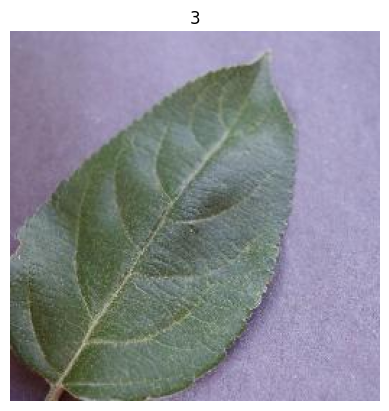

In [149]:
sample = data_train[0]
plt.imshow(sample['image'])
plt.title(sample['label'])
plt.axis("off")
plt.show()

In [150]:
# Verificar tamaños
print(f"Train size: {len(data_train)}")
print(f"Test size: {len(data_test)}")

Train size: 16664
Test size: 4629


In [151]:
labels = data_train.features['label'].names
print(labels)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

## Modelo preentrenado

In [152]:
selected_model = 'facebook/deit-base-patch16-224'
processor = AutoImageProcessor.from_pretrained(selected_model)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [153]:
num_labels = len(labels)

# Adaptamos el modelo
model = AutoModelForImageClassification.from_pretrained(
    selected_model,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
)


Some weights of ViTForImageClassification were not initialized from the model checkpoint at facebook/deit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([38, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([38]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [154]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
])


In [155]:
def transform_dataset(example, transform=None):
    image = example['image']

    if transform:
        image = transform(image)

    inputs = processor(images=image, return_tensors="pt")
    example['pixel_values'] = inputs['pixel_values'].squeeze()
    example['label'] = example['label']

    return example

In [156]:
data_train = data_train.map(lambda x: transform_dataset(x, transform), batched=False)
data_valid = data_valid.map(lambda x:transform_dataset(x), batched=False)
data_test = data_test.map(lambda x: transform_dataset(x), batched=False)

In [157]:
torch.cuda.empty_cache()
gc.collect()

23

In [158]:
def collate_fn(batch):
    pixel_values = [item['pixel_values'] for item in batch]
    labels = [item['label'] for item in batch]
    return {
        'pixel_values': torch.stack(pixel_values),
        'labels': torch.tensor(labels)
    }

In [159]:
eval_dataloader = DataLoader(data_test, batch_size=32, shuffle=False, collate_fn=collate_fn)

In [160]:
data_test

Dataset({
    features: ['image', 'label', 'pixel_values'],
    num_rows: 4629
})

In [161]:
data_train.set_format(type='torch', columns=['pixel_values','label'])
data_valid.set_format(type='torch', columns=['pixel_values', 'label'])
data_test.set_format(type='torch', columns=['pixel_values','label'])

In [162]:
def evaluate_model(model, dataloader, labels, dataset_raw, device='cpu'):
    model.eval()
    model.to(device)

    all_predictions = []
    all_labels = []
    
    # Para las primeras imágenes
    images_to_show = []
    predictions_to_show = []
    labels_to_show = []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            pixel_values = batch['pixel_values'].to(device)
            labels_batch = batch['labels'].to(device)

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

            if i < 1:
                for j in range(min(15, len(labels_batch))):
                    images_to_show.append(dataset_raw[i * dataloader.batch_size + j]['image'])
                    predictions_to_show.append(predictions[j].item())
                    labels_to_show.append(labels_batch[j].item())

    # Convertimos a numpy arrays
    all_labels = np.array(all_labels)
    all_predictions = np.array(all_predictions)

    # Detectar clases presentes en los datos
    present_class_indices = sorted(np.unique(np.concatenate([all_labels, all_predictions])))
    present_class_names = [labels[i] for i in present_class_indices]
    
    # Métricas
    acc = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='macro')
    precision = precision_score(all_labels, all_predictions, average='macro')
    recall = recall_score(all_labels, all_predictions, average='macro')

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score (macro): {f1:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, labels=present_class_indices, target_names=present_class_names))

    # Mostrar imágenes
    plt.figure(figsize=(20, 10))
    for i in range(len(images_to_show)):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images_to_show[i])
        plt.title(f"Pred: {labels[predictions_to_show[i]]}\nTrue: {labels[labels_to_show[i]]}")
        plt.axis('off')
    plt.suptitle("Predicciones vs. Etiquetas verdaderas (primeras 15 imágenes)", fontsize=16)
    plt.tight_layout()
    plt.show()


c:\Proyectos\UBA\VpCIII\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Proyectos\UBA\VpCIII\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Proyectos\UBA\VpCIII\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Proyectos\UBA\VpCIII\venv

Accuracy: 0.0106
F1 Score (macro): 0.0073
Precision (macro): 0.0150
Recall (macro): 0.0330

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.10      0.05      0.07       404
                                 Apple___Black_rot       0.00      0.00      0.00       397
                          Apple___Cedar_apple_rust       0.00      0.00      0.00       353
                                   Apple___healthy       0.00      0.00      0.00       402
                               Blueberry___healthy       0.00      0.00      0.00       363
          Cherry_(including_sour)___Powdery_mildew       0.00      0.00      0.00       337
                 Cherry_(including_sour)___healthy       0.00      0.00      0.00       365
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00       328
                       Corn_(maize)___Common_rust_      

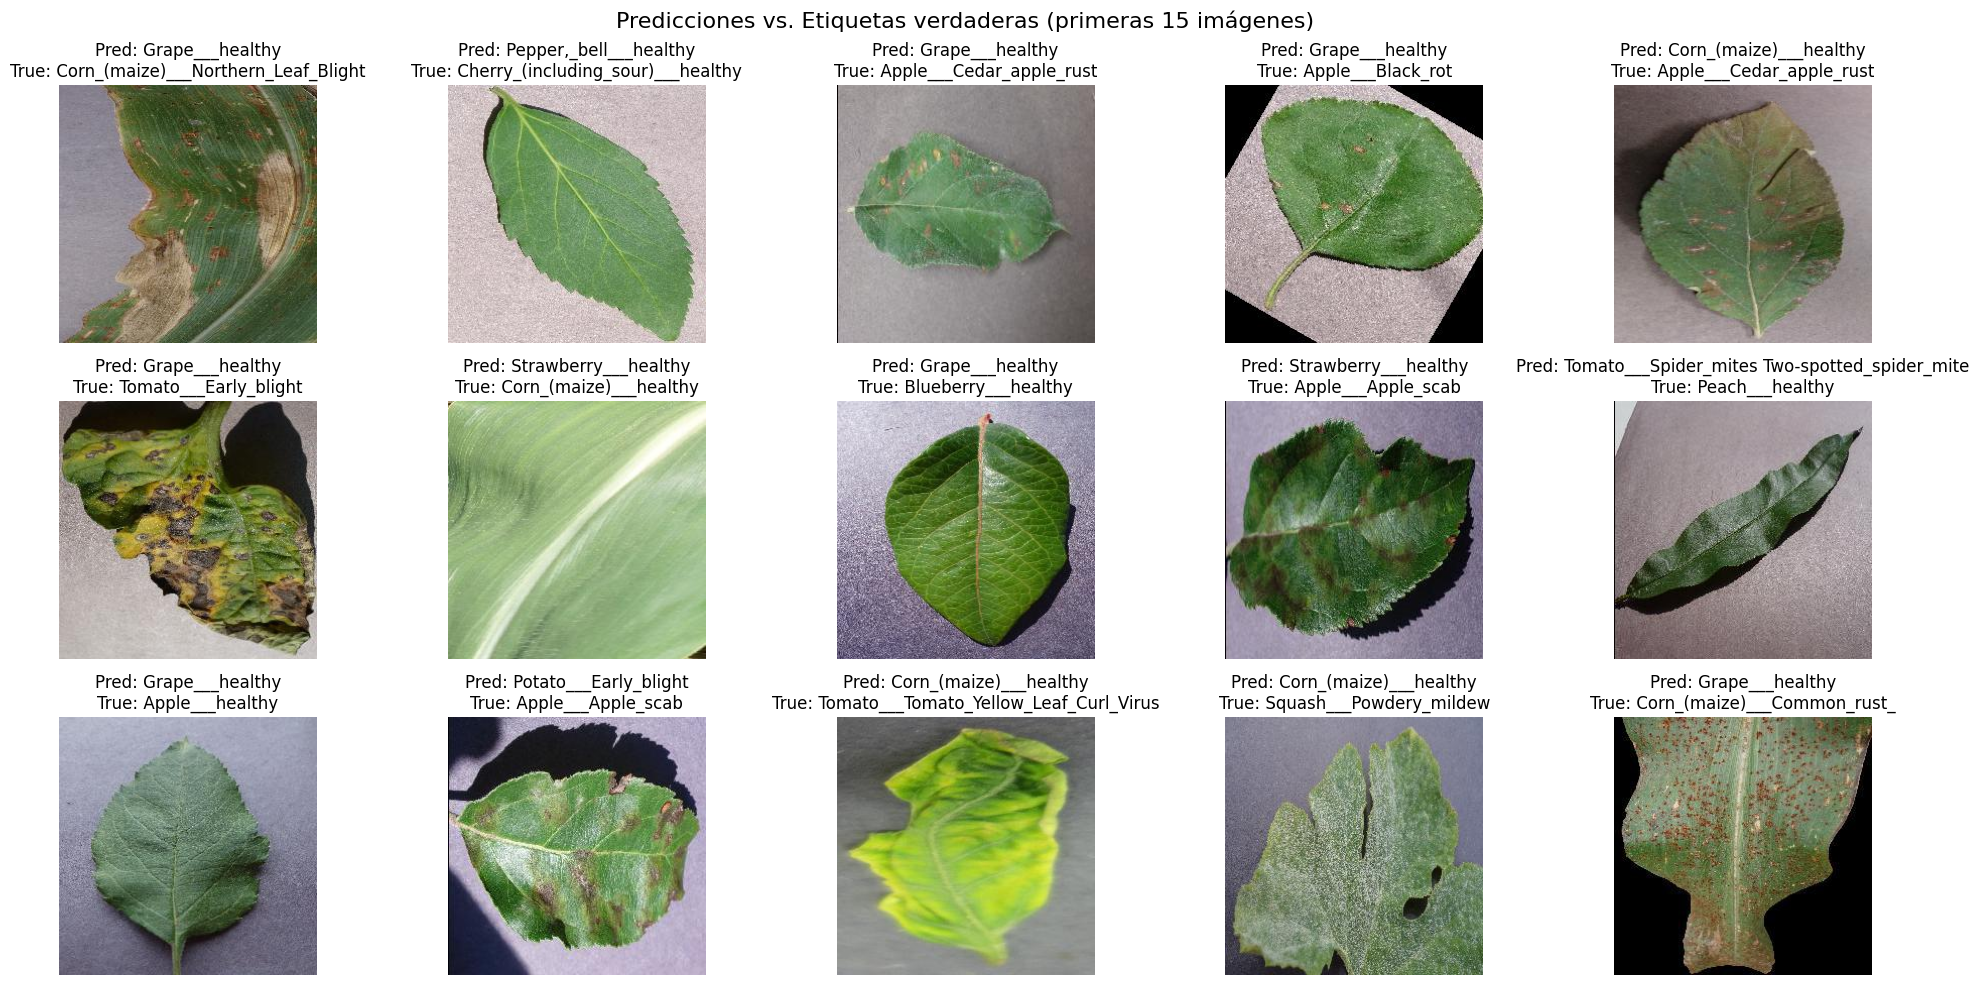

In [163]:
evaluate_model(
    model=model,
    dataloader=eval_dataloader,
    labels=labels,
    dataset_raw=data_test_original,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)


In [164]:
torch.cuda.empty_cache()
gc.collect()

36982

## Fine-tuning del modelo

In [165]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,  
    per_device_eval_batch_size=16, 
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    fp16=True
)

In [166]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [167]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=data_train,
    eval_dataset=data_valid,
    tokenizer=processor,
    compute_metrics=compute_metrics
)

C:\Users\caro_\AppData\Local\Temp\ipykernel_35124\2436116264.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [168]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.103200,0.044678,0.987581
2,0.018900,0.041259,0.989741
3,0.000700,0.019628,0.994060
4,0.000500,0.017661,0.995140
5,0.000300,0.016374,0.995140


TrainOutput(global_step=5210, training_loss=0.06178719814502118, metrics={'train_runtime': 3218.7446, 'train_samples_per_second': 25.886, 'train_steps_per_second': 1.619, 'total_flos': 6.458715849886433e+18, 'train_loss': 0.06178719814502118, 'epoch': 5.0})

In [169]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': 0.01637420244514942, 'eval_accuracy': 0.9951403887688985, 'eval_runtime': 46.7983, 'eval_samples_per_second': 39.574, 'eval_steps_per_second': 2.479, 'epoch': 5.0}


In [170]:
torch.cuda.empty_cache()

Accuracy: 0.9959
F1 Score (macro): 0.9835
Precision (macro): 0.9843
Recall (macro): 0.9840

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00       404
                                 Apple___Black_rot       1.00      1.00      1.00       397
                          Apple___Cedar_apple_rust       1.00      1.00      1.00       353
                                   Apple___healthy       1.00      1.00      1.00       402
                               Blueberry___healthy       1.00      1.00      1.00       363
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       337
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       365
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       1.00      0.99      0.99       328
                       Corn_(maize)___Common_rust_      

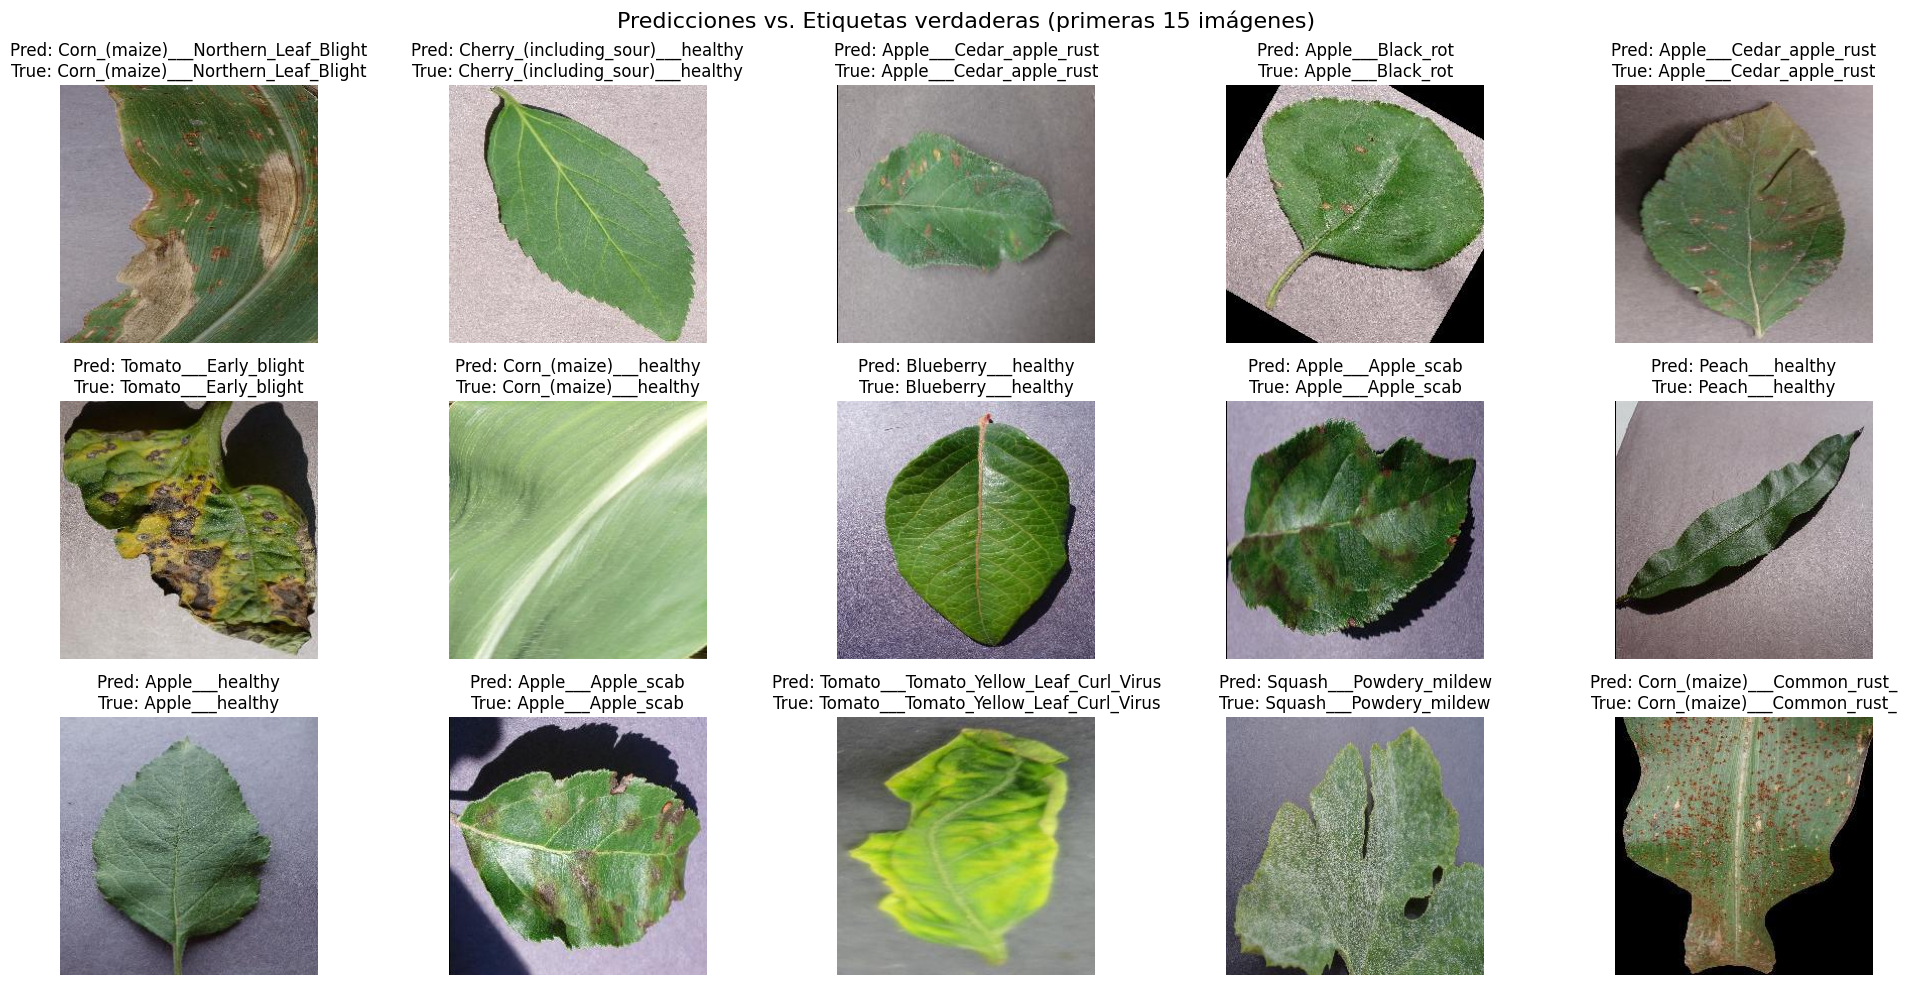

In [171]:
evaluate_model(
    model=model,
    dataloader=eval_dataloader,
    labels=labels,
    dataset_raw=data_test_original,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)


## Respuestas

### 1. Justifique la elección del modelo preentrenado y del dataset.


Modelo preentrenado seleccionado: **facebook/deit-base-patch16-224**

**Justificación:**
- ViT eficiente y ligero: El modelo DeiT (Data-efficient Image Transformer) es una variante del Vision Transformer entrenada con una estrategia más eficiente, permitiendo buenos resultados en clasificación de imágenes con menos datos etiquetados.

- Preentrenamiento generalizado: Está preentrenado en ImageNet, lo cual lo hace apto para transfer learning en tareas de clasificación de imágenes naturales, como es el caso de enfermedades en hojas de plantas.

- Arquitectura versátil: Como modelo basado en atención, no depende tanto de la localización espacial como las CNNs, lo que puede ser útil con imágenes de hojas que presentan patrones en distintas regiones.

Dataset utilizado: **fakewave07/plant-diseases-dataset**

**Justificación:**

- Multiclase y multiespecie: Cubre múltiples cultivos (manzana, uva, maíz, etc.) y diversas enfermedades, lo que representa un desafío realista y diverso para un modelo de clasificación.

- Aplicación práctica relevante: La identificación automática de enfermedades vegetales tiene un valor real en agricultura, lo que justifica experimentar con este tipo de datos.

### 2. Explique el proceso de fine-tuning realizado, especificando los parámetros ajustados y las modificaciones necesarias.


Modificaciones al modelo:

- Adaptación de la capa de salida: Se cambió la capa final del modelo para que se adapte al número de clases en el dataset (num_labels = len(labels)).

- ignore_mismatched_sizes=True: Esto permite reemplazar la capa final preentrenada (pensada para ImageNet con 1000 clases) por una nueva, sin errores por discrepancias de tamaño.

Transformaciones aplicadas a los datos:

- Aumento de datos en entrenamiento:

   - RandomHorizontalFlip y RandomRotation(15°): Técnicas comunes para mejorar la robustez del modelo a variaciones espaciales.

- Normalización automática por el AutoImageProcessor: Adapta las imágenes a lo que espera el modelo preentrenado (tamaño, canales, normalización).

Parámetros de entrenamiento (TrainingArguments):

- learning_rate=2e-5: Pequeño para evitar sobreajustar la base preentrenada demasiado rápido.

- num_train_epochs=5: Suficientes para ver mejoras sin sobreentrenamiento.

- per_device_train_batch_size=16: Equilibrio entre estabilidad y uso de memoria GPU.

- eval_strategy="epoch" + load_best_model_at_end=True: Evalúa cada época y guarda el mejor modelo según rendimiento en validación.

- fp16=True: Uso de media precisión para acelerar el entrenamiento en GPU compatibles.

### 3. Evalúe el rendimiento del modelo preentrenado sin ajustes y compárelo con los resultados obtenidos tras el fine-tuning, discutiendo las mejoras o diferencias observadas.

#### Modelo preentrenado (sin fine-tuning):
- **Accuracy:** 0.0106
- **F1 Score (macro):** 0.0073
- **Precision (macro):** 0.0150
- **Recall (macro):** 0.0330

**Interpretación:**
- El modelo no tiene conocimiento específico sobre las clases del dataset.
- Aunque está preentrenado en ImageNet, no logra generalizar a la tarea de clasificación de enfermedades en hojas de plantas.
- El rendimiento es prácticamente aleatorio, con una ligera predilección por algunas clases (e.g. Grape___healthy con alto recall pero bajo f1-score).
- No es útil en esta forma para una tarea de clasificación real.


#### Modelo tras fine-tuning:
- **Accuracy:** 0.9959
- **F1 Score (macro):** 0.9835
- **Precision (macro):** 0.9843
- **Recall (macro):** 0.9840

**Interpretación:**
- Después del fine-tuning con imágenes reales de hojas y enfermedades, el modelo ajusta sus pesos para reconocer patrones específicos.
- Se observa una mejora sustancial y consistente en todas las métricas.
- El modelo clasifica correctamente incluso clases minoritarias (de solo 20 imágenes), manteniendo alta precisión y recall.
- El rendimiento es excelente y demuestra la eficacia del aprendizaje por transferencia en tareas de clasificación especializada.


#### 📊 Comparación resumen:

| Métrica     | Preentrenado | Fine-tuned |
|-------------|--------------|------------|
| Accuracy    | 0.0106       | 0.9959     |
| F1 Macro    | 0.0073       | 0.9835     |
| Precision   | 0.0150       | 0.9843     |
| Recall      | 0.0330       | 0.9840     |



### Conclusión:
El fine-tuning transforma un modelo genérico en una herramienta altamente especializada para la clasificación de enfermedades en plantas. Las mejoras son evidentes y cuantificables en todos los aspectos.